## Problem Statement

Healthcare insurance costs differ significantly across individuals due to variations in demographic, physical, and lifestyle factors. For insurance providers, understanding these cost drivers is crucial for accurate pricing and risk assessment, while for individuals, it helps bring clarity to how personal choices and characteristics impact medical expenses.

This project focuses on analyzing a dataset of 1,338 individuals from the United States, containing features such as age, Body Mass Index (BMI), smoking status, number of dependents, and gender. The goal is to explore how these variables influence the medical charges billed by health insurance companies.

By applying regression analysis, we aim to develop a model that can predict insurance charges based on individual attributes. In parallel, data visualization techniques will be used to uncover trends, correlations, and patterns within the dataset. This project serves as a beginner-friendly introduction to regression modeling and exploratory data analysis using real-world healthcare data.


### Importing the Library


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import chi2_contingency,chi2,f_oneway,binom,kruskal,ttest_ind
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

- Load the data

In [ ]:
df=pd.read_csv('/content/medical-charges.csv')

In [ ]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.isna().sum() # there is no null values in the following data

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()# we found one duplicate value in the data

np.int64(1)

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


- visualization

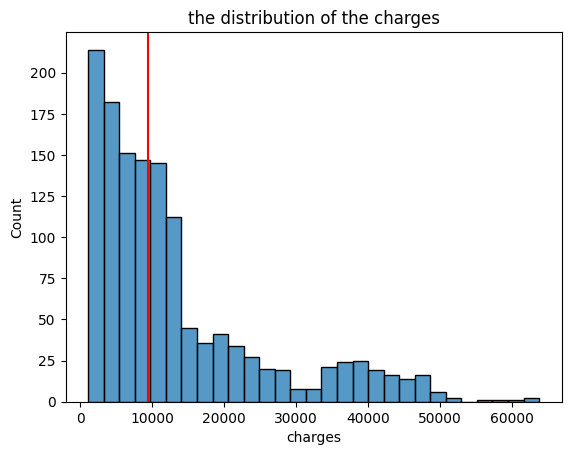

In [ ]:
median=df['charges'].median()
sns.histplot(df['charges'])
plt.xlabel("charges")
plt.ylabel("Count")
plt.axvline(median, color='red')
plt.title("the distribution of the charges")
plt.show()

- in the above histogram we  can see maximum audience prefer 10000-20000 range rather then 60,000

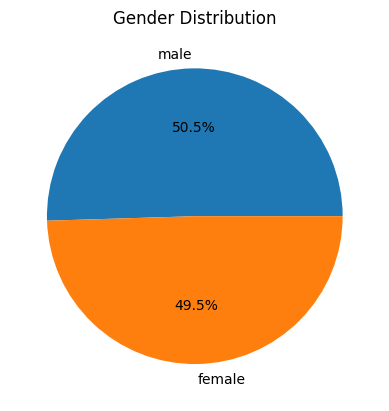

In [ ]:
c=df['sex'].value_counts()
plt.pie(c, labels=c.index,autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

- in the above pie chart we can see a clear and good distribution of gender

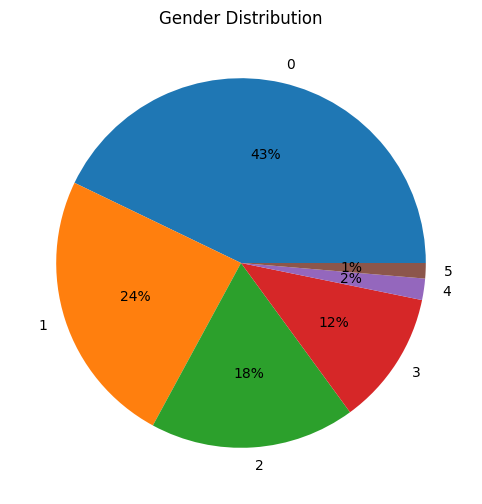

In [ ]:
plt.figure(figsize=(10,6))
c=df['children'].value_counts()
plt.pie(c, labels=c.index,autopct='%1.f%%')
plt.title("Gender Distribution")
plt.show()

- The pie chart illustrates the gender distribution in the dataset, showing an uneven representation across categories.  
One category dominates the population, while the remaining groups account for progressively smaller proportions.


/tmp/ipython-input-3872990098.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=df['smoker'],y=df['charges'],palette='viridis')


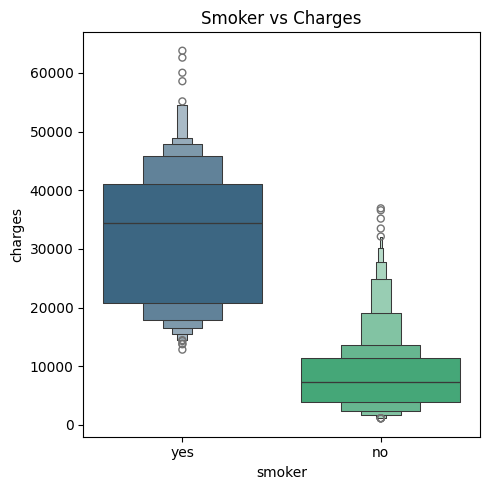

In [ ]:
plt.figure(figsize=(5,5))
sns.boxenplot(x=df['smoker'],y=df['charges'],palette='viridis')
plt.title("Smoker vs Charges")
plt.tight_layout()
plt.show()


The boxen plot shows a clear difference in insurance charges between smokers and non-smokers.  
Smokers incur significantly higher and more variable medical charges, with numerous high-value outliers compared to non-smokers.


Text(0.5, 1.0, 'BMI relation  Charges')

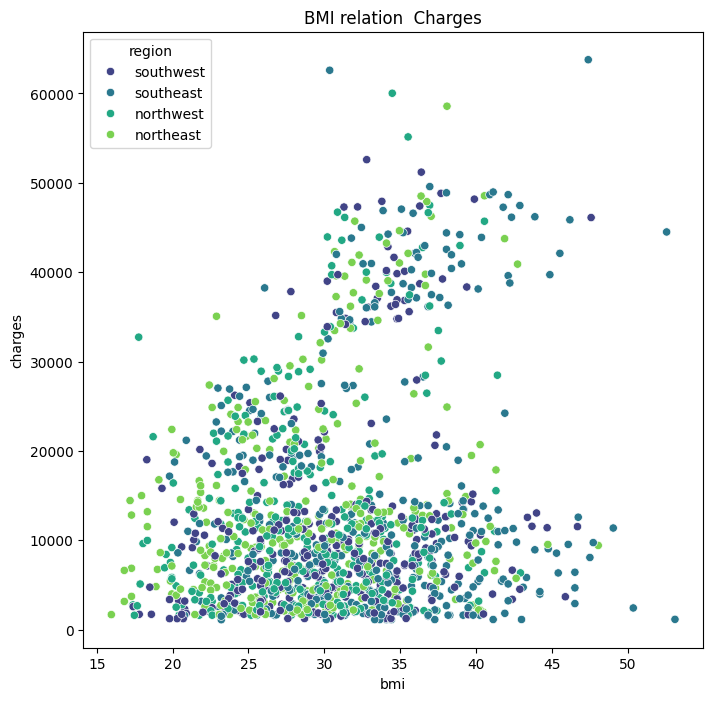

In [ ]:
plt.figure(figsize=(8,8))
sns.scatterplot(x=df['bmi'],y=df['charges'],hue=df['region'],palette='viridis')
plt.title("BMI relation  Charges")

The scatter plot illustrates a positive relationship between BMI and insurance charges, with higher BMI values generally associated with increased costs.  
While this trend is consistent across regions, there is noticeable variability, indicating that BMI alone does not fully explain insurance charges.


/tmp/ipython-input-609734073.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=h.index,y=h.values,palette='viridis')


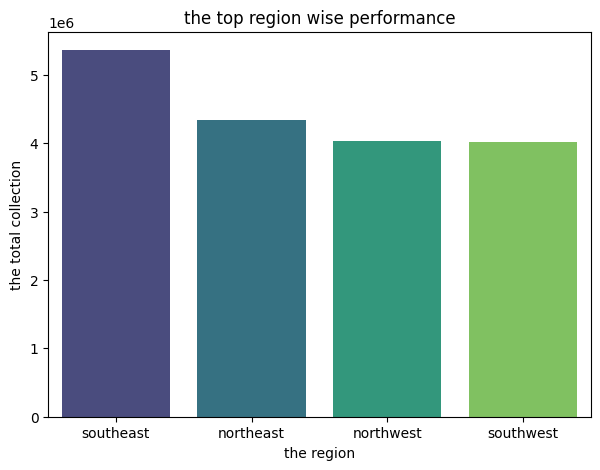

In [ ]:
plt.figure(figsize=(7,5))
h=df.groupby('region')['charges'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=h.index,y=h.values,palette='viridis')
plt.title("the top region wise performance")
plt.ylabel("the total collection")
plt.xlabel("the region")
plt.show()

The bar chart highlights region-wise total insurance charges, showing the Southeast as the highest contributing region.  
Other regions display relatively similar total collections, indicating a more balanced distribution compared to the Southeast.


/tmp/ipython-input-783898252.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x=df['sex'],y=df['charges'],palette='viridis')
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 12.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 11.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 36.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categori

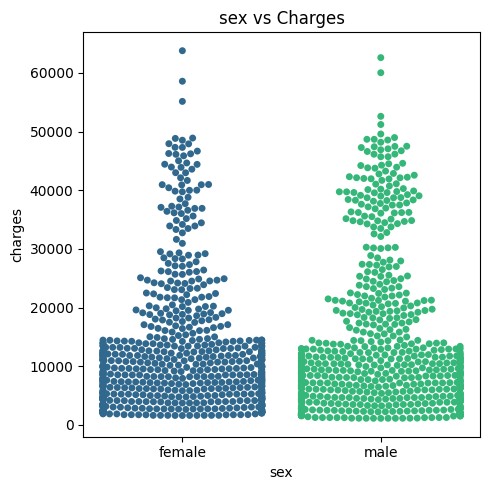

In [ ]:
plt.figure(figsize=(5,5))
sns.swarmplot(x=df['sex'],y=df['charges'],palette='viridis')
plt.title("sex vs Charges")
plt.tight_layout()
plt.show()

The swarm plot compares insurance charges across genders, showing a similar overall distribution for males and females.  
While both groups exhibit wide variability and high-cost outliers, males appear to have slightly higher charge dispersion at the upper range.


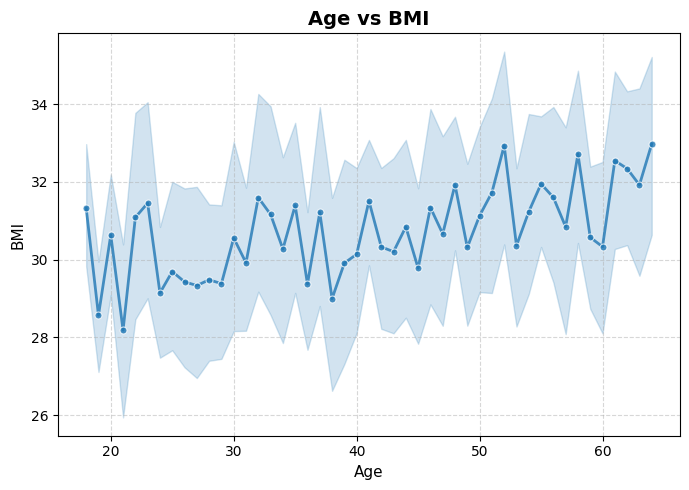

In [ ]:
plt.figure(figsize=(7, 5))

sns.lineplot(
    data=df, x='age', y='bmi',marker='o',markersize=5,linewidth=2,alpha=0.8
)

plt.title("Age vs BMI", fontsize=14, fontweight='bold')
plt.xlabel("Age", fontsize=11)
plt.ylabel("BMI", fontsize=11)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


The line plot shows a gradual upward trend in BMI as age increases, indicating a positive relationship between the two variables.  
Despite noticeable fluctuations at individual ages, the overall pattern suggests BMI tends to rise slightly with age.


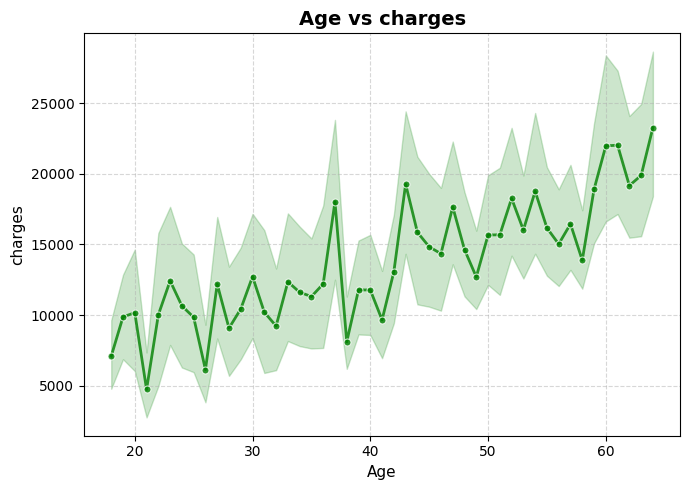

In [ ]:
plt.figure(figsize=(7, 5))

sns.lineplot(
    data=df, x='age', y='charges',marker='o',markersize=5,linewidth=2,alpha=0.8,color='green'
)

plt.title("Age vs charges", fontsize=14, fontweight='bold')
plt.xlabel("Age", fontsize=11)
plt.ylabel("charges", fontsize=11)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


The plot demonstrates a clear upward trend in insurance charges as age increases, indicating higher medical costs for older individuals.  
Although there are fluctuations across ages, the overall pattern suggests age is a strong contributing factor to insurance charges.


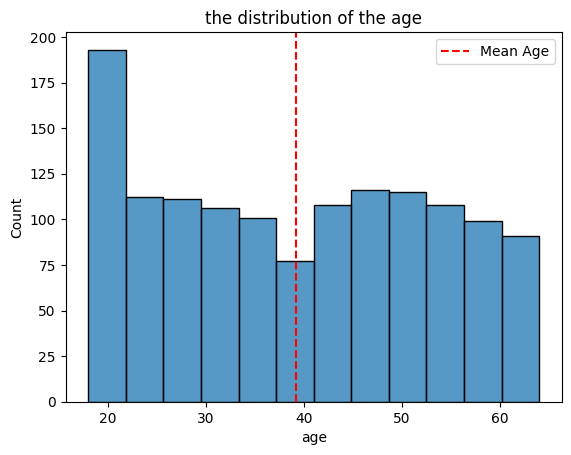

In [ ]:
sns.histplot(df['age'])
plt.axvline(df['age'].mean(), color='red', linestyle='--',label='Mean Age')
plt.xlabel("age")
plt.ylabel("Count")
plt.title("the distribution of the age")
plt.legend()
plt.show()

The highest concentration of individuals is observed between the ages of approximately 20 and 30, where the frequency of observations is greatest.  
This indicates that younger adults form a larger portion of the dataset compared to older age groups.


In [ ]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif bmi < 25:
        return 'normal'
    elif bmi < 30:
        return 'overweight'
    else:
        return 'obese'
df['bmi_category'] = df['bmi'].apply(bmi_category)



In [ ]:
def age_group(age):
    if age <= 30:
        return 'young'
    elif age <= 45:
        return 'adult'
    elif age <= 60:
        return 'middle_aged'
    else:
        return 'senior'

df['age_group'] = df['age'].apply(age_group)


In [ ]:
df['family_size'] = df['children'] + 1

/tmp/ipython-input-3961227997.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_bmi, x='bmi_category', y='charges', palette='viridis')


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

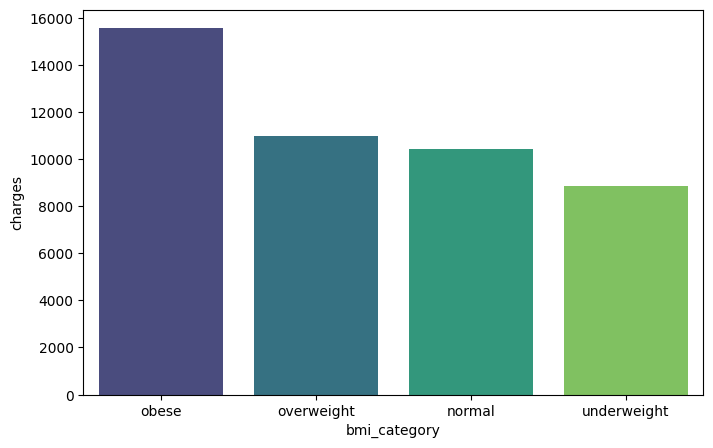

In [ ]:
# Calculate average charges per BMI category
top_bmi = df.groupby('bmi_category')['charges'].mean().sort_values(ascending=False).head(10).reset_index()


# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=top_bmi, x='bmi_category', y='charges', palette='viridis')
plt


The bar chart shows that individuals in the obese BMI category incur the highest average insurance charges.  
Charges decrease progressively from overweight to normal and are lowest for the underweight category, indicating a strong relationship between BMI level and healthcare costs.


/tmp/ipython-input-476187613.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_age, x='age_group', y='charges', palette='viridis')


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

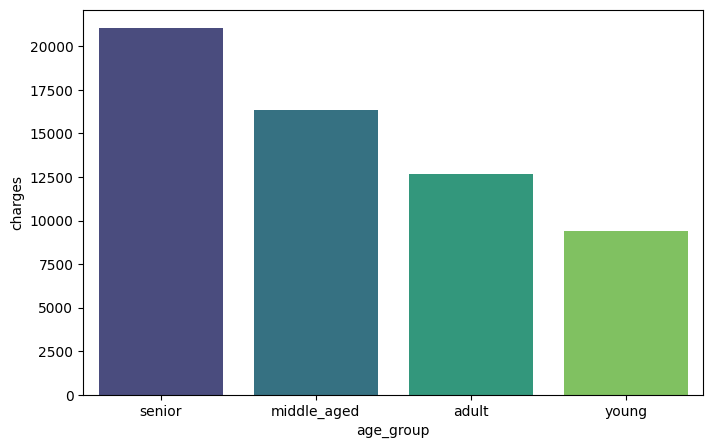

In [ ]:
top_age = df.groupby('age_group')['charges'].mean().sort_values(ascending=False).head(10).reset_index()


# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=top_age, x='age_group', y='charges', palette='viridis')
plt


The bar chart shows that senior individuals have the highest average insurance charges, followed by middle-aged adults.  
Younger age groups incur significantly lower charges, indicating that insurance costs tend to increase with age.


/tmp/ipython-input-2735816032.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['family_size'],y=df['charges'],palette='viridis')


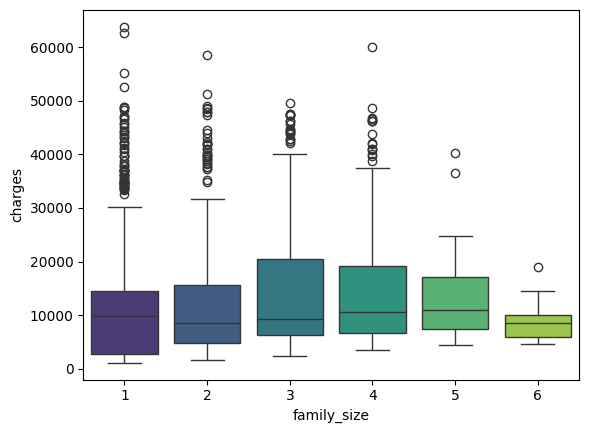

In [ ]:
sns.boxplot(x=df['family_size'],y=df['charges'],palette='viridis')
plt.show()

The box plot illustrates how insurance charges vary with family size, showing an overall increase in median charges as family size grows.  
Larger families exhibit greater variability and more high-cost outliers, suggesting higher and less pr


## STATISTICS

In [ ]:
import pandas as pd



stats = pd.DataFrame({
    "mean": df.mean(numeric_only=True),
    "median": df.median(numeric_only=True),
    "mode": df.mode(numeric_only=True).iloc[0],
    "min": df.min(numeric_only=True),
    "max": df.max(numeric_only=True),
    "sum": df.sum(numeric_only=True),
    "skewness": df.skew(numeric_only=True),
    "std": df.std(numeric_only=True),
    "variance": df.var(numeric_only=True)
})

stats


,mean,median,mode,min,max,sum,skewness,std,variance
age,39.222139,39.0000,18.0000,18.0000,64.00000,5.244000e+04,0.054781,14.044333,1.972433e+02
bmi,30.663452,30.4000,32.3000,15.9600,53.13000,4.099704e+04,0.283914,6.100468,3.721571e+01
children,1.095737,1.0000,0.0000,0.0000,5.00000,1.465000e+03,0.937421,1.205571,1.453402e+00
charges,13279.121487,9386.1613,1121.8739,1121.8739,63770.42801,1.775419e+07,1.515391,12110.359656,1.466608e+08
family_size,2.095737,2.0000,1.0000,1.0000,6.00000,2.802000e+03,0.937421,1.205571,1.453402e+00


In [ ]:
df.head(3)

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,family_size
0,19,female,27.90,0,yes,southwest,16884.9240,overweight,young,1
1,18,male,33.77,1,no,southeast,1725.5523,obese,young,2
2,28,male,33.00,3,no,southeast,4449.4620,obese,young,4


- non parameter test

In [ ]:

alpha=0.05
t=pd.crosstab(df['region'],df['smoker'])
observed=t.values
rows, cols = t.shape
dof = (rows - 1) * (cols - 1)
e=chi2_contingency(observed)
expected=e.expected_freq
chisquared = np.sum((observed - expected) ** 2 / expected)
critical=chi2.ppf(1-alpha,dof)
if chisquared>critical:
  print(f"reject null hypothesis the value is {chisquared}")
else:
  print("accept null hypothesis")


accept null hypothesis


In [ ]:
alpha = 0.05

t1 = pd.crosstab(df['bmi_category'], df['age_group'])
observed1 = t1.values

rows1, cols1 = t1.shape
dof1 = (rows1 - 1) * (cols1 - 1)

chi2_stat1, p1, _, expected1 = chi2_contingency(observed1)
chisquared1 = np.sum((observed1 - expected1) ** 2 / expected1)

# critical value
critical1 = chi2.ppf(1 - alpha, dof1)

if chisquared1 > critical1:
    print(f"Reject H0: BMI category and age group are associated (χ² = {chisquared1:.3f})")
else:
    print("Fail to reject H0: No association between BMI category and age group")


Reject H0: BMI category and age group are associated (χ² = 26.319)


In [ ]:

t2 = pd.crosstab(df['bmi_category'], df['region'])
observed2 = t2.values

rows2, cols2 = t2.shape
dof2 = (rows2 - 1) * (cols2 - 1)

chi2_stat2, p2, _, expected2 = chi2_contingency(observed2)
chisquared2 = np.sum((observed2 - expected2) ** 2 / expected2)

critical2 = chi2.ppf(1 - alpha, dof2)

if chisquared2 > critical2:
    print(f"Reject H0: BMI category and region are associated (χ² = {chisquared2:.3f})")
else:
    print("Fail to reject H0: No association between BMI category and region")


Reject H0: BMI category and region are associated (χ² = 57.811)


- parameter test

In [ ]:


alpha = 0.05

# groups
a = df[df['age_group'] == 'young']['charges']
b = df[df['age_group'] == 'adult']['charges']
c = df[df['age_group'] == 'middle_aged']['charges']
d = df[df['age_group'] == 'senior']['charges']

# ANOVA
f_stat, p_value = f_oneway(a, b, c, d)

print("F-statistic:", f_stat)
print("p-value:", p_value)

# Interpretation
if p_value <= alpha:
    print("Reject the null hypothesis: at least one group mean is significantly different.")
else:
    print("Fail to reject the null hypothesis: no significant difference among group means.")


F-statistic: 39.83212581911331
p-value: 1.1896308728844113e-24
Reject the null hypothesis: at least one group mean is significantly different.


In [ ]:
alpha=0.05
a1=df[df['smoker']=='yes']['charges']
b1=df[df['smoker']=='no']['charges']
f_stats,p_value=ttest_ind(a1,b1,equal_var=False)
print("F-statistic:", f_stats)
print("p-value:", p_value)
if p_value <= alpha:
    print("Reject the null hypothesis: at least one group mean is significantly different.")
else:
  print("Fail to reject the null hypothesis: no significant difference among group means.")

F-statistic: 32.7423097372529
p-value: 6.261720774727631e-103
Reject the null hypothesis: at least one group mean is significantly different.


In [ ]:
df['bmi_category'].unique()

array(['overweight', 'obese', 'normal', 'underweight'], dtype=object)

In [ ]:
from scipy.stats import kruskal
alpha=0.05
a2=df[df['bmi_category']=='overweight']['charges']
b2=df[df['bmi_category']=='normal']['charges']
c2=df[df['bmi_category']=='obese']['charges']
d2=df[df['bmi_category']=='underweight']['charges']
h_stat, p_value=kruskal(a2,b2,c2,d2)
print("F-statistic:",h_stat)
print("p-value:", p_value)
if p_value <= alpha:
    print("Reject the null hypothesis: at least one group mean is significantly different.")
else:
  print("Fail to reject the null hypothesis: no significant difference among group means.")

F-statistic: 17.047863697498542
p-value: 0.0006909023796032061
Reject the null hypothesis: at least one group mean is significantly different.


/tmp/ipython-input-1838339199.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal, overweight, obese], labels=['Normal', 'Overweight', 'Obese'])


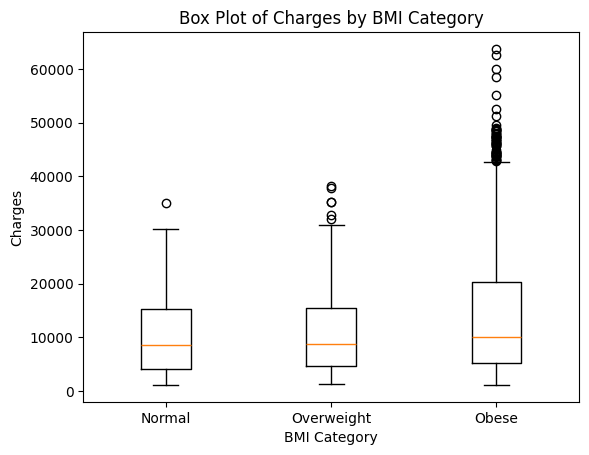

In [ ]:
import matplotlib.pyplot as plt

# select 3 categories
normal = df[df['bmi_category'] == 'normal']['charges']
overweight = df[df['bmi_category'] == 'overweight']['charges']
obese = df[df['bmi_category'] == 'obese']['charges']

# box plot
plt.figure()
plt.boxplot([normal, overweight, obese], labels=['Normal', 'Overweight', 'Obese'])
plt.xlabel('BMI Category')
plt.ylabel('Charges')
plt.title('Box Plot of Charges by BMI Category')
plt.show()


- probability

In [ ]:
df.head(4)

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,family_size
0,19,female,27.900,0,yes,southwest,16884.92400,overweight,young,1
1,18,male,33.770,1,no,southeast,1725.55230,obese,young,2
2,28,male,33.000,3,no,southeast,4449.46200,obese,young,4
3,33,male,22.705,0,no,northwest,21984.47061,normal,adult,1


/tmp/ipython-input-1164864470.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal, overweight, obese], labels=['Normal', 'Overweight', 'Obese'])


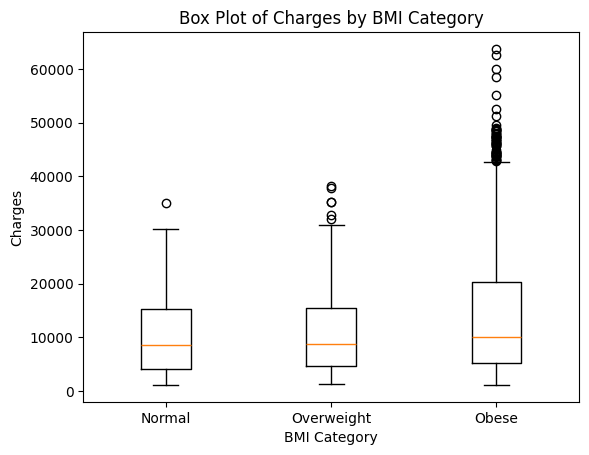

In [ ]:
import matplotlib.pyplot as plt

# select 3 categories
normal = df[df['bmi_category'] == 'normal']['charges']
overweight = df[df['bmi_category'] == 'overweight']['charges']
obese = df[df['bmi_category'] == 'obese']['charges']

# box plot
plt.figure()
plt.boxplot([normal, overweight, obese], labels=['Normal', 'Overweight', 'Obese'])
plt.xlabel('BMI Category')
plt.ylabel('Charges')
plt.title('Box Plot of Charges by BMI Category')
plt.show()

- probabiity

In [ ]:
# probabily a customer will be obese
df2=df.copy()

In [ ]:
df['bmi_category'].unique()

array(['overweight', 'obese', 'normal', 'underweight'], dtype=object)

In [ ]:
df2['bmi_category']=df['bmi_category'].map({"obese":1,"overweight":1,"normal":0, 'underweight':0})


In [ ]:
from scipy.stats import binom
p=df2['bmi_category'].mean()
n=10
r=binom(n=n,p=p)
r1=r.pmf(1)
print(r1)

1.9028446127541357e-06


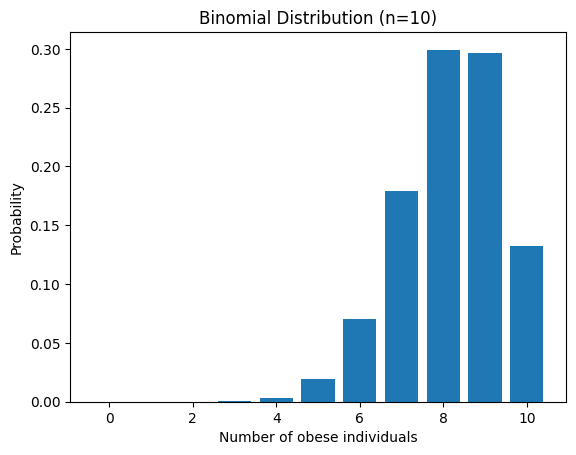

In [ ]:
x = np.arange(0, n + 1)
y = binom.pmf(x, n, p)
plt.figure()
plt.bar(x, y)
plt.xlabel('Number of obese individuals')
plt.ylabel('Probability')
plt.title('Binomial Distribution (n=10)')
plt.show()


In [ ]:
df2['age_group'].unique()

array(['young', 'adult', 'middle_aged', 'senior'], dtype=object)

In [ ]:
df2['age_group']=df2['age_group'].map({'young':0, 'adult':0, 'middle_aged':1, 'senior':1})

0.055231273059054016


<BarContainer object of 11 artists>

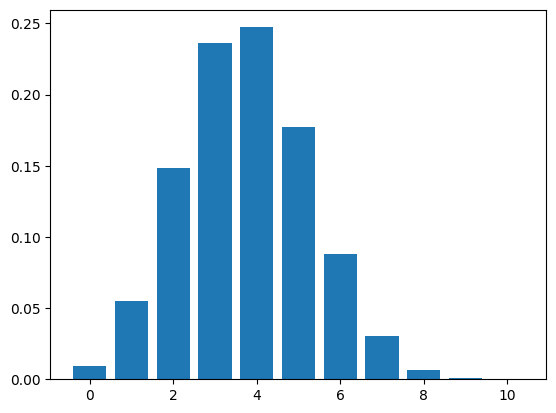

In [ ]:
p1=df2['age_group'].mean()
n=10
r2=binom(n=n,p=p1)
r3=r2.pmf(1)
print(r3)
x1=np.arange(0,n+1)
y1=binom.pmf(x1,n,p1)
plt.figure()
plt.bar(x1,y1)

#  Statistical Analysis Summary

**Significance level:** α = 0.05  

---

## Chi-Square Tests of Independence

### Region vs Smoker
- **Decision:** Fail to reject H₀  
- **Conclusion:** Region and smoker status are independent.

### BMI Category vs Age Group
- **χ² = 26.319**
- **Decision:** Reject H₀  
- **Conclusion:** BMI category is significantly associated with age group.

### BMI Category vs Region
- **Decision:** Fail to reject H₀  
- **Conclusion:** BMI category and region are independent.

---

## One-Way ANOVA (Charges vs Age Group)

- **F = 39.83**, **p < 0.001**
- **Decision:** Reject H₀  
- **Conclusion:** Mean medical charges differ across age groups.

---

## Independent Samples t-Test (Charges vs Smoker)

- **t = 32.74**, **p < 0.001**
- **Decision:** Reject H₀  
- **Conclusion:** Smokers and non-smokers have significantly different medical charges.

---

## Kruskal–Wallis Test (Charges vs BMI Category)

- **H = 17.05**, **p = 0.00069**
- **Decision:** Reject H₀  
- **Conclusion:** Charges differ significantly across BMI categories.

---

## Binomial Distribution

- Binary outcome: Obese (1) vs Not Obese (0)
- **P(X = 1 obese out of 10) = 0.0061**
- **P(X = 1 from age group out of 10) = 0.0552**

**Visualization:**  
Bar plots were used to illustrate the binomial probability distributions.


## MACHINE LEARNING

In [ ]:
df.head(2)

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,family_size
0,19,female,27.90,0,yes,southwest,16884.9240,overweight,young,1
1,18,male,33.77,1,no,southeast,1725.5523,obese,young,2


In [ ]:

df['region_code'] = df['region'].map({
    'southwest': 0,
    'southeast': 1,
    'northwest': 2,
    'northeast': 3
})
df['bmi_category_code'] = df['bmi_category'].map({
    'underweight': 0,
    'normal': 1,
    'overweight': 2,
    'obese': 3

})
df['age_group_code'] = df['age_group'].map({
    'young': 0,
    'adult': 1,
    'middle_aged': 2,
    'senior': 3
})



In [ ]:
df.drop(columns=['age_group', 'bmi_category', 'region'], inplace=True)


In [ ]:
le=LabelEncoder()
df['smoker']=le.fit_transform(df['smoker'])

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_cols = num_cols.drop([
    'region_code',
    'bmi_category_code',
    'age_group_code'
], errors='ignore')
num_cols.drop("charges")


Index(['age', 'bmi', 'children', 'smoker', 'family_size'], dtype='object')

In [ ]:
n1=num_cols.drop("charges")

In [ ]:
n1

Index(['age', 'bmi', 'children', 'smoker', 'family_size'], dtype='object')

In [ ]:
c1=Pipeline(steps=[("imputing",SimpleImputer(strategy="median")),("scaling",StandardScaler())])
# not required no cat variables c2=Pipeline(steps=["encoding",LabelEncoder()])

In [ ]:
c3=ColumnTransformer(transformers=[("num",c1,n1)])

In [ ]:
Q1=df['charges'].quantile(0.25)
Q3=df['charges'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df['charges']=np.where((df['charges']<lower_bound) | (df['charges']>upper_bound),df['charges'].median(),df['charges'])
# has the volume of data is less we didnt remove outlier we replaced it

In [ ]:
df = df.drop(
    columns=['region_code', 'bmi_category_code', 'age_group_code'],
    errors='ignore'
)

In [ ]:
x=df.drop(columns=['charges'],inplace=False)
y=df['charges']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
results=[]


In [ ]:
x_train=c3.fit_transform(x_train)
x_test=c3.transform(x_test)

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    colsample_bytree=0.7,
    gamma=0.1,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    min_samples_leaf=1,
    min_samples_split=10,
    n_estimators=100,
    missing=float("nan"),
    random_state=42
)

model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:33:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=5, min_samples_leaf=1,
             min_samples_split=10, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, ...)

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
y1=model.predict(x_test)
r2=r2_score(y_test,y1)
mse=mean_squared_error(y_test,y1)
mae=mean_absolute_error(y_test,y1)
print(mse , mae , r2)
results.append({
        "model": "LinearRegression",
        "r2_score": r2_score(y_test, y1)
    })


8628341.27961975 1819.4042025553174 0.6424667554668995


In [ ]:
import joblib

joblib.dump(model, "model.pkl")


['model.pkl']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1337 non-null   int64  
 1   sex          1337 non-null   object 
 2   bmi          1337 non-null   float64
 3   children     1337 non-null   int64  
 4   smoker       1337 non-null   int64  
 5   charges      1337 non-null   float64
 6   family_size  1337 non-null   int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 115.9+ KB


In [ ]:
model1=RandomForestRegressor()
model1.fit(x_train,y_train)
y2=model1.predict(x_test)
r2=r2_score(y_test,y2)
mse=mean_squared_error(y_test,y2)
mae=mean_absolute_error(y_test,y2)
print(mse , mae , r2)
results.append({
        "model": "RandomForest",
        "r2_score": r2_score(y_test, y2)
    })

In [ ]:
model2=XGBRegressor()
model2.fit(x_train,y_train)
y3=model2.predict(x_test)
r2=r2_score(y_test,y3)
mse=mean_squared_error(y_test,y3)
mae=mean_absolute_error(y_test,y3)
print(mse , mae , r2)
results.append({
        "model": "xgbregression",
        "r2_score": r2_score(y_test, y3)
    })

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],   # L1
    'reg_lambda': [1, 1.5, 2], # L2
    'min_samples_split': [2, 5, 10],  # sklearn-style
    'min_samples_leaf': [1, 2, 4]
}


In [ ]:
xgb2=RandomizedSearchCV(model2,param_grid,n_iter=30,scoring="neg_root_mean_squared_error", n_jobs=-1, cv=5)

In [ ]:
xgb2.fit(x_train,y_train)

In [ ]:

xgb2.fit(x_train,y_train)
y4=xgb2.predict(x_test)
r2=r2_score(y_test,y4)
mse=mean_squared_error(y_test,y4)
mae=mean_absolute_error(y_test,y4)
print(mse , mae , r2)
results.append({
        "model": "xgb with tuning",
        "r2_score": r2_score(y_test, y4)
    })

In [ ]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


In [ ]:
search = RandomizedSearchCV(model1,rf_param_grid,n_iter=30,cv=5,scoring='neg_root_mean_squared_error',random_state=42,n_jobs=-1)


In [ ]:


search.fit(x_train, y_train)

y5 = search.predict(x_test)

r2 = r2_score(y_test, y5)
mse = mean_squared_error(y_test, y5)
mae = mean_absolute_error(y_test, y5)

print(mse, mae, r2)


In [ ]:
results.append({
        "model": "Randomforest tuned",
        "r2_score": r2_score(y_test, y5)
    })

In [ ]:
base=[
    ("linear_regression",model),
    ("random_forest",search),
    ("xgboost",xgb2)
]

In [ ]:
meta=RandomForestRegressor()

In [ ]:
f=StackingRegressor(estimators=base,final_estimator=meta,cv=5,n_jobs=-1)

In [ ]:
f.fit(x_train,y_train)


In [ ]:
yf=f.predict(x_test)
r2=r2_score(y_test,yf)
mse=mean_squared_error(y_test,yf)
mae=mean_absolute_error(y_test,yf)
print(mse , mae , r2)
results.append({
        "model": "StackingRegression",
        "r2_score": r2_score(y_test, yf)
    })

In [ ]:
model_score=pd.DataFrame(results)

In [ ]:
model_score

In [ ]:
model_score_sorted = model_score.sort_values(
    by="r2_score",
    ascending=False
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="model",
    y="r2_score",
    data=model_score_sorted
)

## Final Conclusion

This project aimed to analyze and predict healthcare insurance charges based on demographic, physical, and lifestyle factors such as age, BMI, smoking status, number of dependents, and gender. Using regression modeling and exploratory data analysis on a dataset of 1,338 individuals from the United States, we evaluated how these attributes influence medical insurance costs.

Multiple regression models were implemented and compared using the R² score as the primary evaluation metric. The results showed that **ensemble-based and tuned machine learning models significantly outperform simpler models** in capturing the complex, non-linear relationships present in the data.

Among all the models tested, **XGBoost with hyperparameter tuning achieved the highest R² score**, indicating its superior ability to explain variance in insurance charges. **Random Forest (tuned)** and **Stacking Regression** also performed strongly, reinforcing the effectiveness of ensemble learning techniques. In contrast, **Linear Regression demonstrated the lowest performance**, suggesting that insurance costs cannot be accurately modeled using a purely linear approach.

### Key Insights

- **Smoking status and BMI** play a major role in driving higher insurance charges.
- **Age** shows a strong positive correlation with medical costs.
- **Hyperparameter tuning** significantly improves model performance.
- **Non-linear models** are better suited for healthcare cost prediction.

### Conclusion

The findings from this project highlight the importance of advanced regression techniques for healthcare cost prediction. By accurately modeling insurance charges, such approaches can assist insurance providers in risk assessment and pricing strategies, while also helping individuals understand how personal and lifestyle factors impact their medical expenses.

### Recommended Model

✅ **XGBoost with Hyperparameter Tuning**

